In [ ]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder

In [ ]:
train=pd.read_csv('D:\4projects\Instagram_Account_Authentication\data\Insta_train.csv')
test=pd.read_csv('D:\4projects\Instagram_Account_Authentication\data\Insta_test.csv')

In [ ]:
train.shape

(576, 12)

In [ ]:
test.shape

(120, 12)

In [ ]:
train.describe()

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,5.760000e+02,576.000000,576.000000
mean,0.701389,0.163837,1.460069,0.036094,0.034722,22.623264,0.116319,0.381944,107.489583,8.530724e+04,508.381944,0.500000
std,0.458047,0.214096,1.052601,0.125121,0.183234,37.702987,0.320886,0.486285,402.034431,9.101485e+05,917.981239,0.500435
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.900000e+01,57.500000,0.000000
50%,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.505000e+02,229.500000,0.500000
75%,1.000000,0.310000,2.000000,0.000000,0.000000,34.000000,0.000000,1.000000,81.500000,7.160000e+02,589.500000,1.000000
max,1.000000,0.920000,12.000000,1.000000,1.000000,150.000000,1.000000,1.000000,7389.000000,1.533854e+07,7500.000000,1.000000


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   profile pic           576 non-null    int64  
 1   nums/length username  576 non-null    float64
 2   fullname words        576 non-null    int64  
 3   nums/length fullname  576 non-null    float64
 4   name==username        576 non-null    int64  
 5   description length    576 non-null    int64  
 6   external URL          576 non-null    int64  
 7   private               576 non-null    int64  
 8   #posts                576 non-null    int64  
 9   #followers            576 non-null    int64  
 10  #follows              576 non-null    int64  
 11  fake                  576 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 54.1 KB


In [ ]:
train.drop_duplicates(inplace=True)
train.rename(columns={
    '#posts': 'posts',
    '#followers': 'followers',
    '#follows': 'follows'
}, inplace=True)

test.rename(columns={
    '#posts': 'posts',
    '#followers': 'followers',
    '#follows': 'follows'
}, inplace=True)


In [ ]:
print(train.shape)
train.head(5)

(574, 12)


,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,posts,followers,follows,fake
0,1,0.27,0,0.0,0,53,0,0,32,1000,955,0
1,1,0.00,2,0.0,0,44,0,0,286,2740,533,0
2,1,0.10,2,0.0,0,0,0,1,13,159,98,0
3,1,0.00,1,0.0,0,82,0,0,679,414,651,0
4,1,0.00,2,0.0,0,0,0,1,6,151,126,0


In [ ]:
print(train['profile pic'].value_counts())
print(train['external URL'].value_counts())
print(train['name==username'].value_counts())
print(train['private'].value_counts())
print(train['fake'].value_counts())

profile pic
1    402
0    172
Name: count, dtype: int64
external URL
0    507
1     67
Name: count, dtype: int64
name==username
0    554
1     20
Name: count, dtype: int64
private
0    354
1    220
Name: count, dtype: int64
fake
0    287
1    287
Name: count, dtype: int64


In [ ]:
cat_col=['profile pic','external URL','name==username',"private",'fake']
train[cat_col]=train[cat_col].astype(bool)
test[cat_col]=test[cat_col].astype(bool)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 574 entries, 0 to 575
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   profile pic           574 non-null    bool   
 1   nums/length username  574 non-null    float64
 2   fullname words        574 non-null    int64  
 3   nums/length fullname  574 non-null    float64
 4   name==username        574 non-null    bool   
 5   description length    574 non-null    int64  
 6   external URL          574 non-null    bool   
 7   private               574 non-null    bool   
 8   posts                 574 non-null    int64  
 9   followers             574 non-null    int64  
 10  follows               574 non-null    int64  
 11  fake                  574 non-null    bool   
dtypes: bool(5), float64(2), int64(5)
memory usage: 38.7 KB


In [ ]:
train.head(5)

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,posts,followers,follows,fake
0,True,0.27,0,0.0,False,53,False,False,32,1000,955,False
1,True,0.00,2,0.0,False,44,False,False,286,2740,533,False
2,True,0.10,2,0.0,False,0,False,True,13,159,98,False
3,True,0.00,1,0.0,False,82,False,False,679,414,651,False
4,True,0.00,2,0.0,False,0,False,True,6,151,126,False


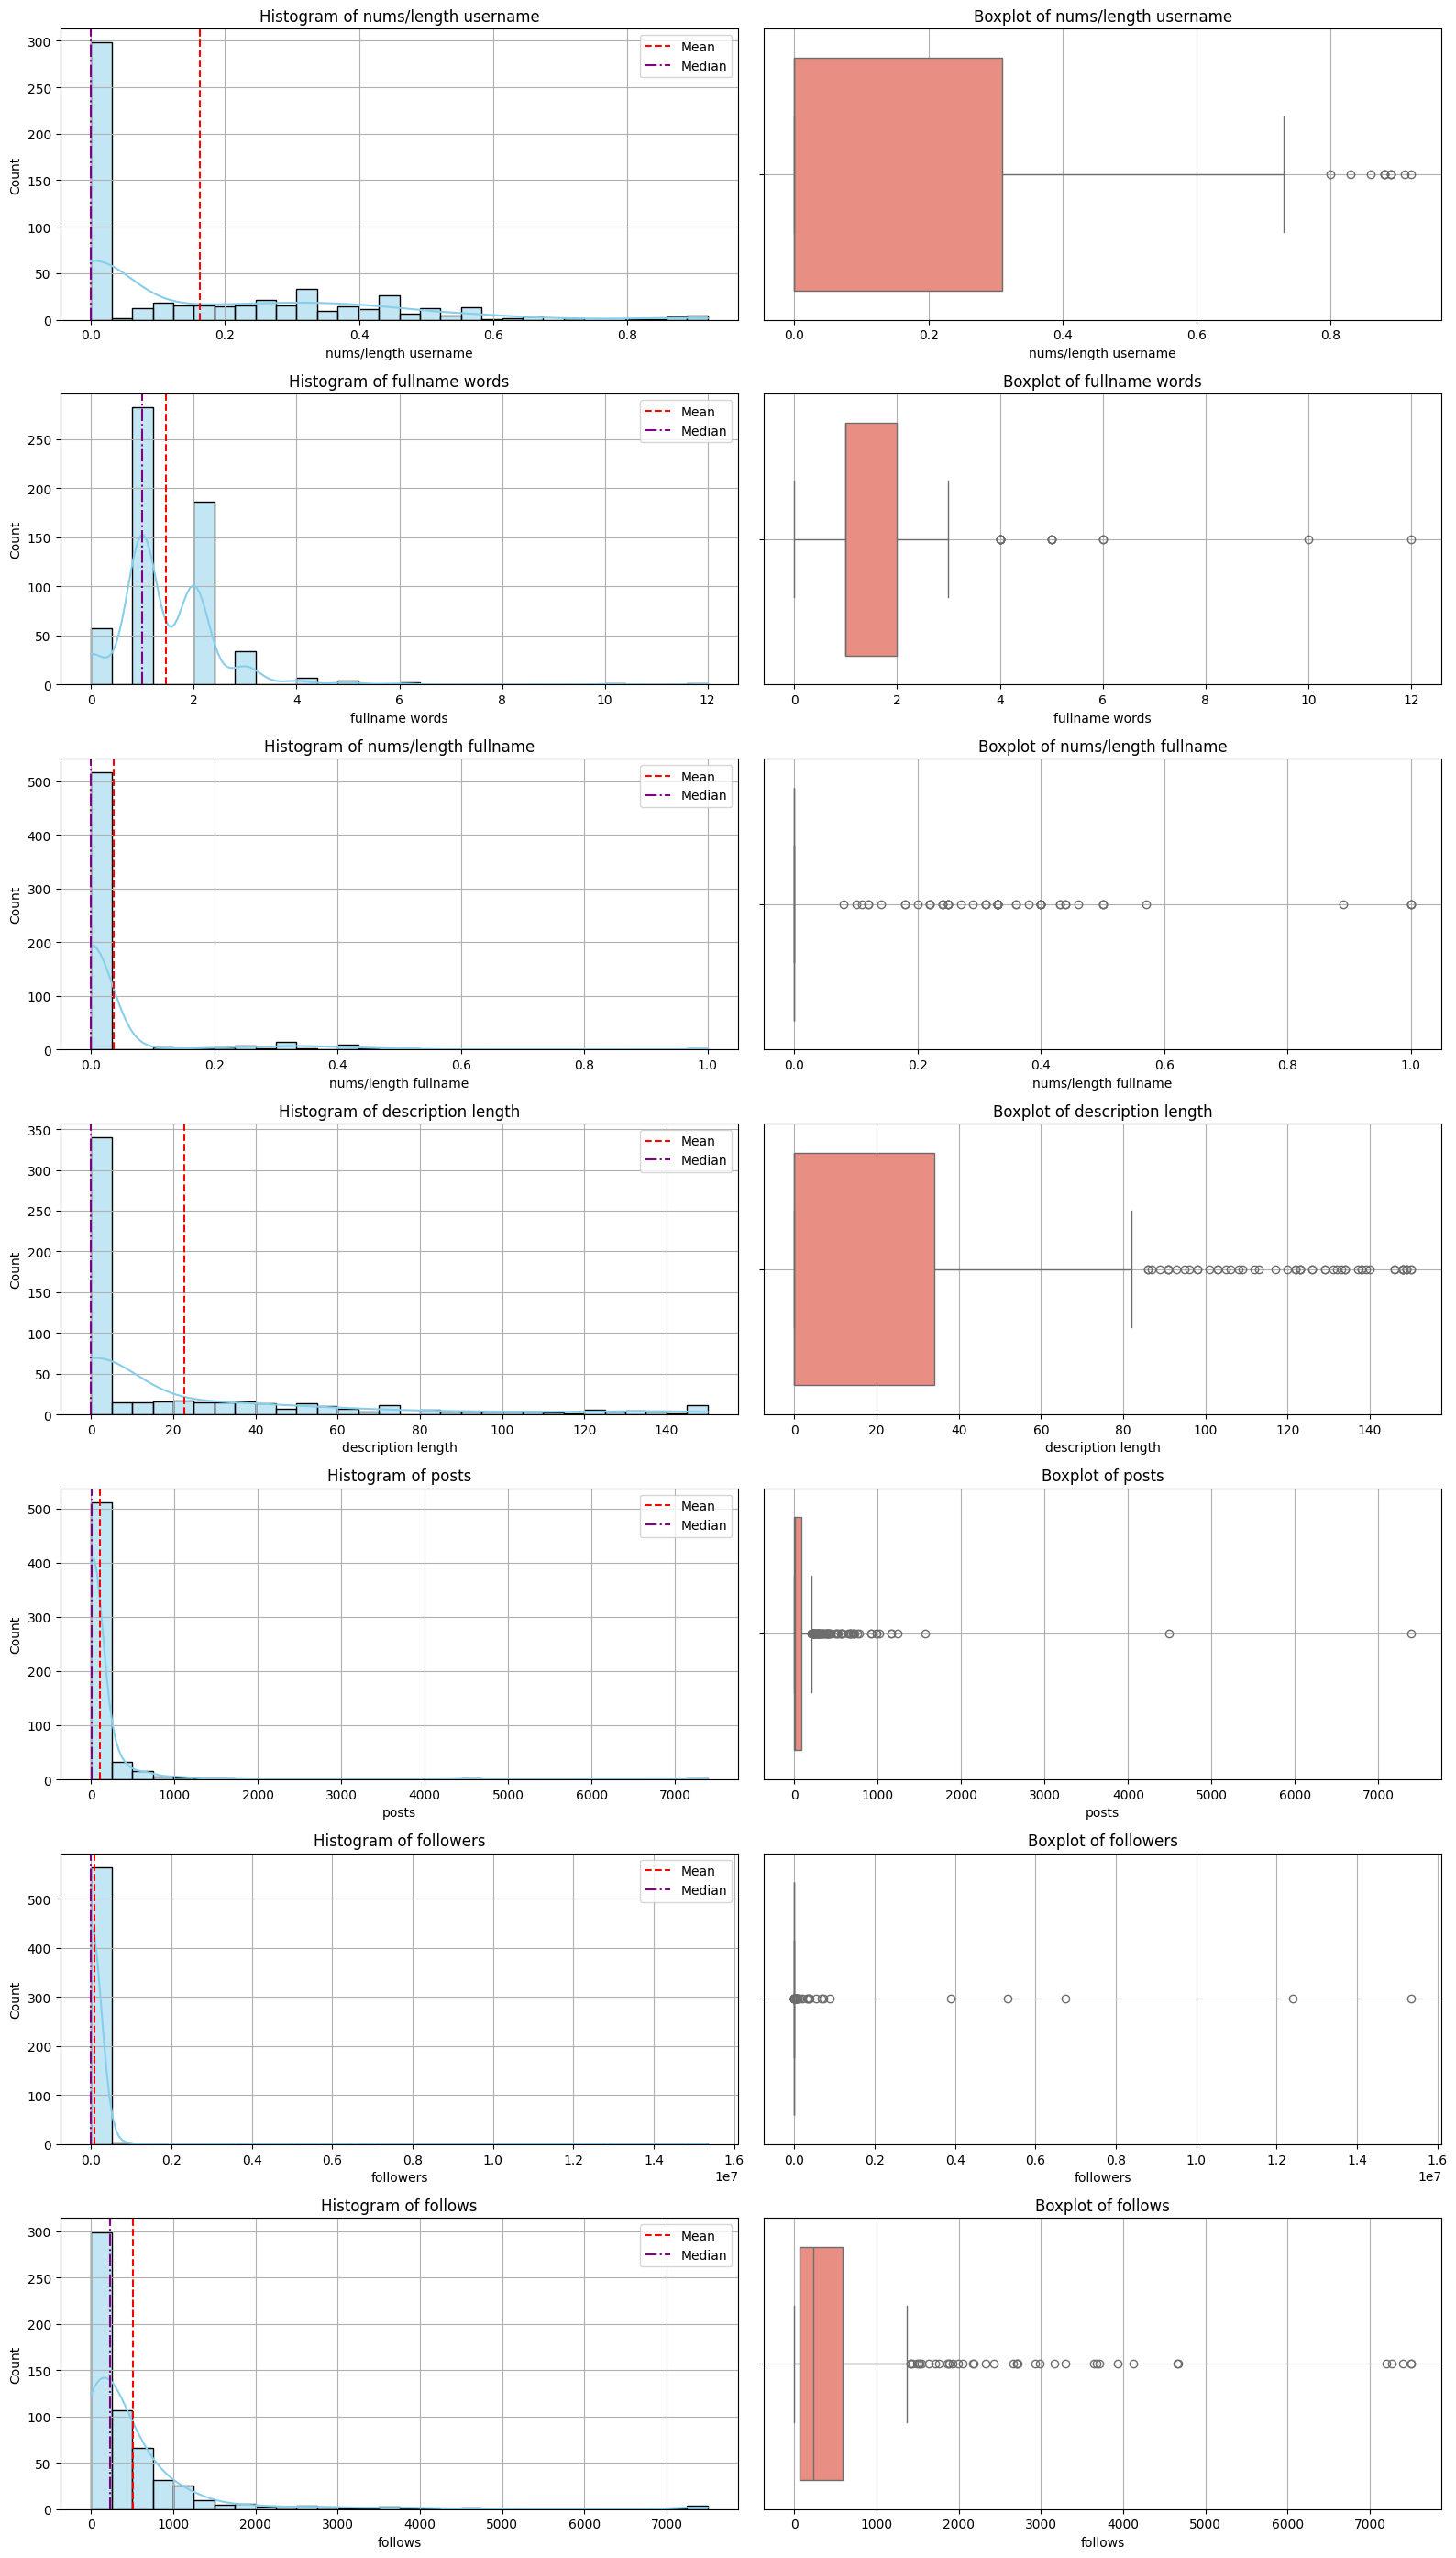

In [ ]:
num_cols=['nums/length username',	'fullname words',	'nums/length fullname', 'description length', 'posts',	'followers',	'follows']


fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(16, 28))

for i, col in enumerate(num_cols):
    ax = axes[i, 0]
    sns.histplot(train[col], kde=True, bins=30, color='skyblue', ax=ax)
    ax.axvline(train[col].mean(), color='red', linestyle='--', label='Mean')
    ax.axvline(train[col].median(), color='purple', linestyle='-.', label='Median')
    ax.set_title(f'Histogram of {col}')
    ax.legend()
    ax.grid(True)

    ax = axes[i, 1]
    sns.boxplot(x=train[col], color='salmon', ax=ax)
    ax.set_title(f'Boxplot of {col}')
    ax.grid(True)

plt.tight_layout()
plt.show()



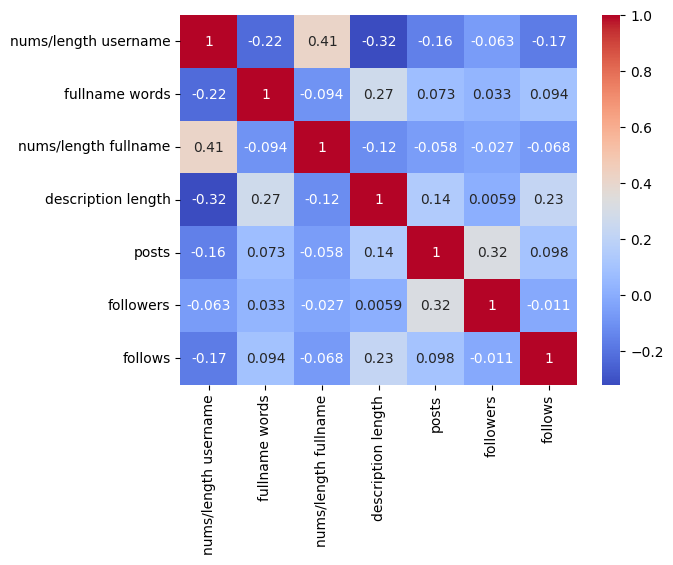

In [ ]:
sns.heatmap(train[num_cols].corr(),annot=True,cmap="coolwarm")
plt.show()

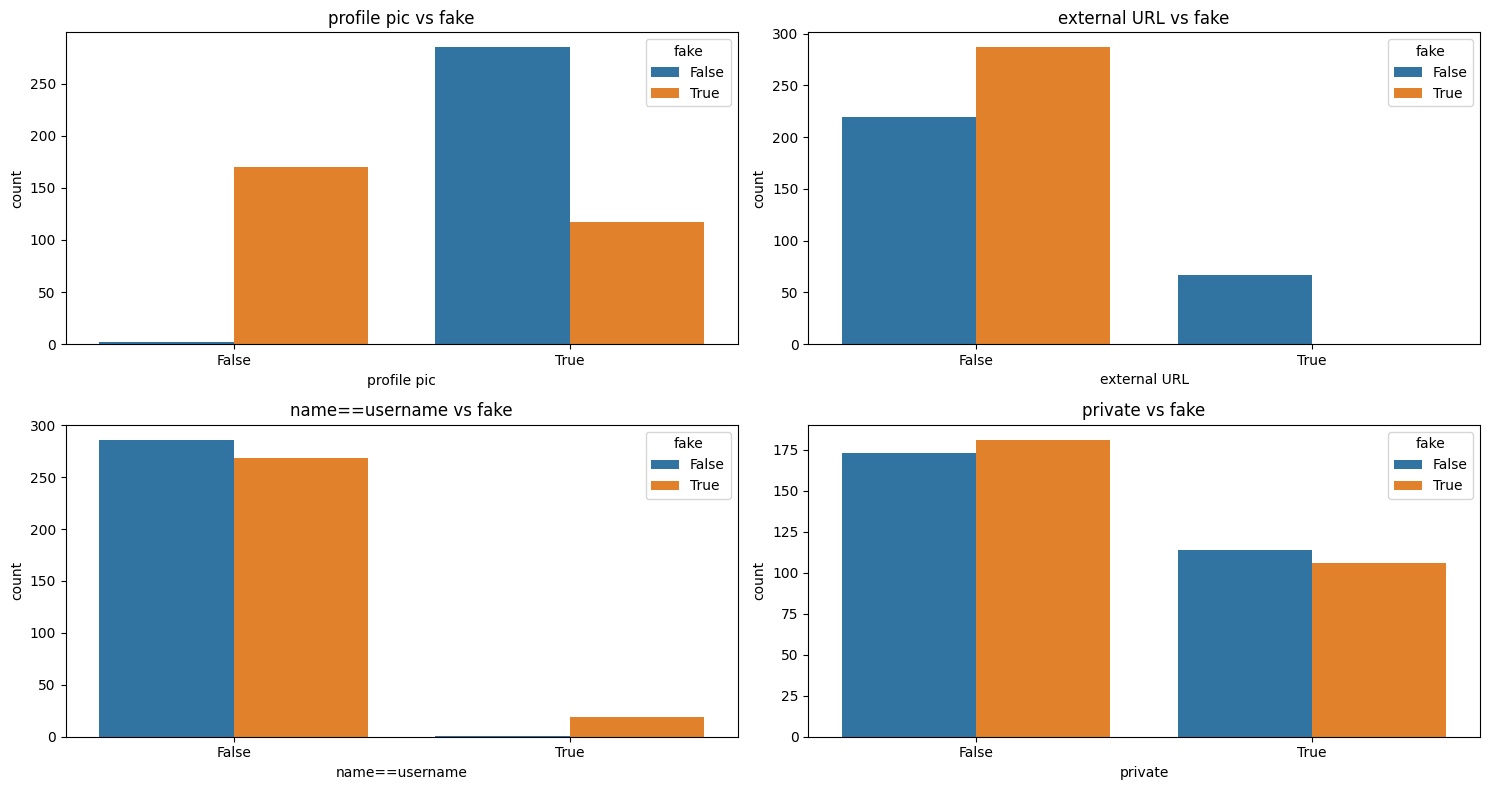

In [ ]:
fig,ax=plt.subplots(2,2,figsize=(15,8))
ax=ax.flatten()
for i,col in enumerate(cat_col):
  if col != 'fake':
    sns.countplot(x=col,data=train,hue='fake',ax=ax[i])
    ax[i].set_title(f"{col} vs fake")
plt.tight_layout()
plt.show()

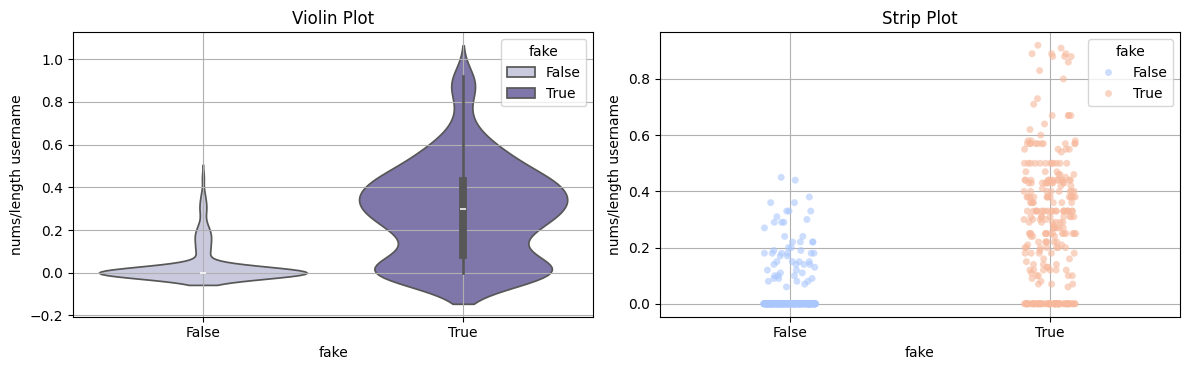

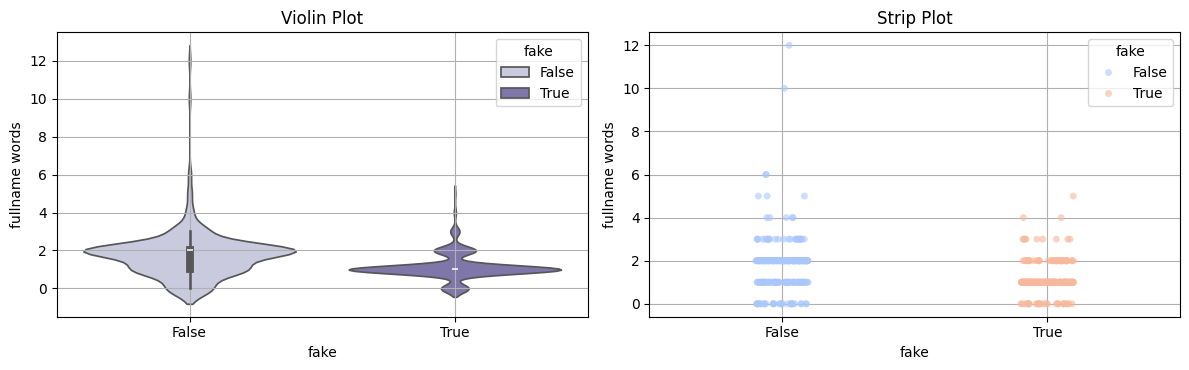

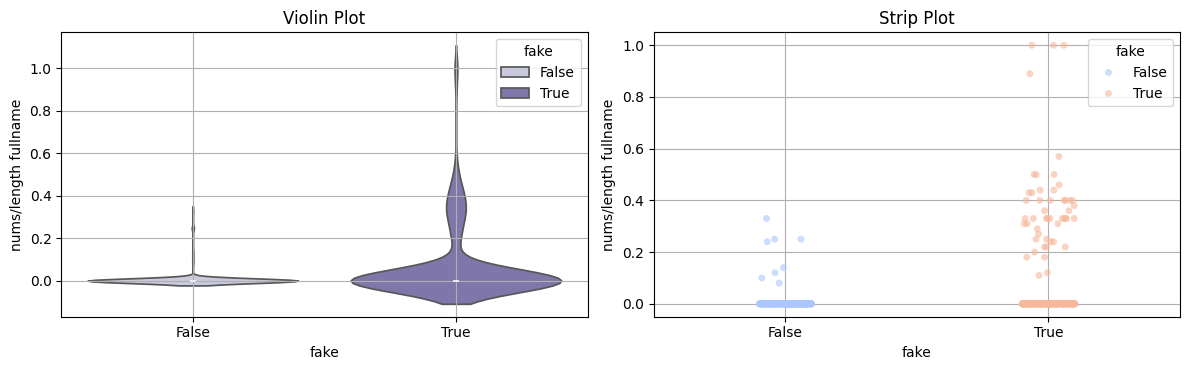

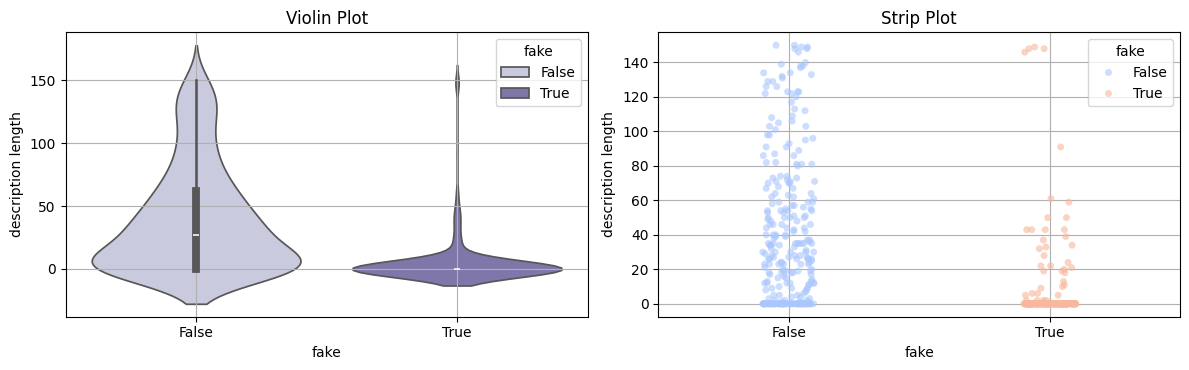

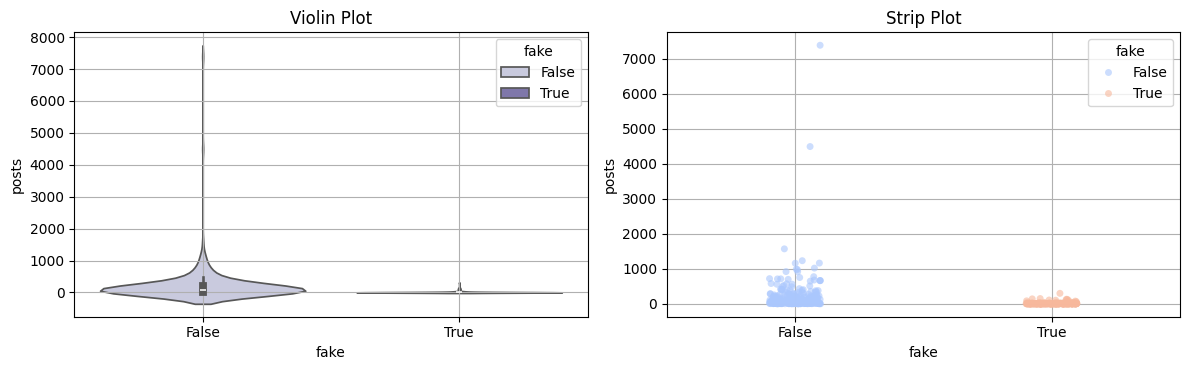

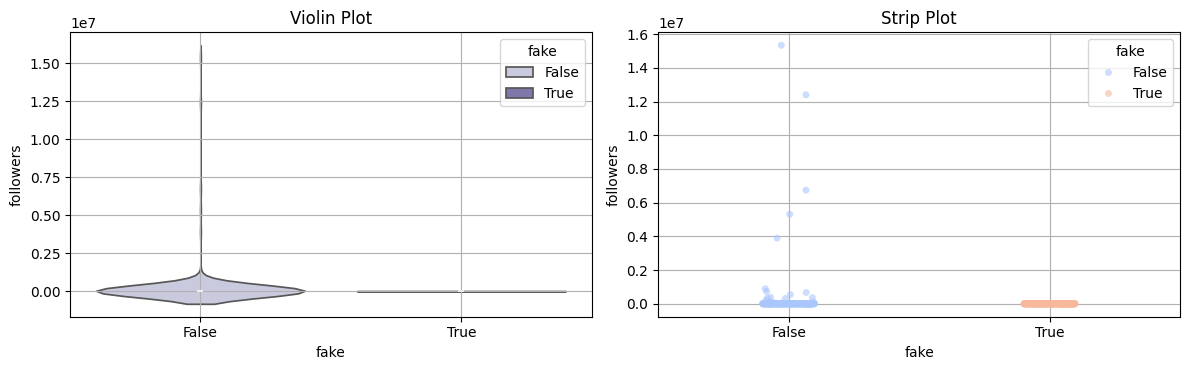

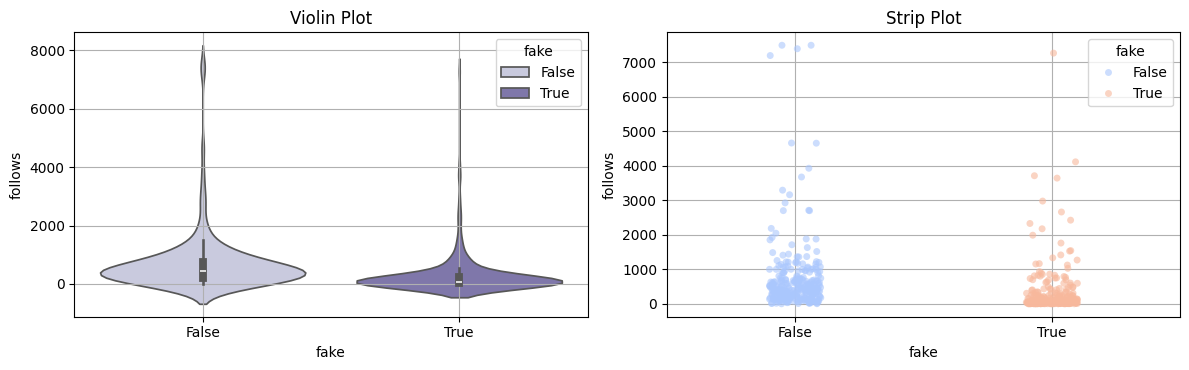

In [ ]:
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.violinplot(x='fake', y=col, data=train,hue='fake', palette='Purples', ax=axes[0])
    axes[0].set_title('Violin Plot')
    axes[0].grid(True)

    sns.stripplot(x='fake', y=col, data=train, palette='coolwarm',hue='fake', ax=axes[1], jitter=True, alpha=0.6)
    axes[1].set_title('Strip Plot')
    axes[1].grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


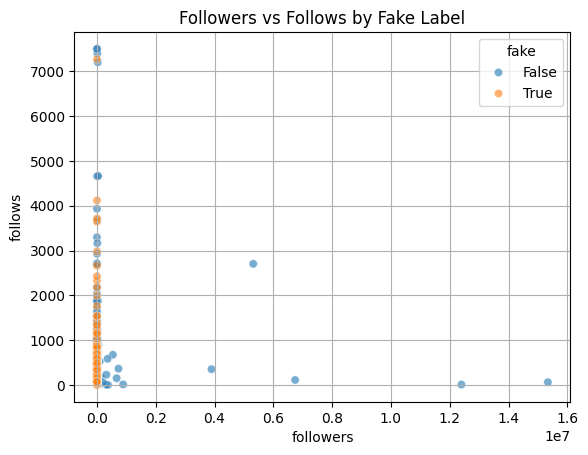

In [ ]:
sns.scatterplot(x='followers', y='follows', hue='fake', data=train, alpha=0.6)
plt.title('Followers vs Follows by Fake Label')
plt.grid(True)
plt.show()


In [ ]:
def add_features(df):
  df['follower_follow_ratio'] = df['followers'] / (df['follows'] + 1)
  df['follow_post_ratio'] = df['follows'] / (df['posts'] + 1)

  df['SuspicionScore'] = (
      (~df['external URL']).astype(int) +
      (~df['profile pic']).astype(int) +
      (df['name==username']).astype(int) +
      (df['posts'] == 0).astype(int) +
      (df['followers'] < 50).astype(int) +
      ((df['follower_follow_ratio'] < 0.1) &
      (df['followers'] > 1000)).astype(int) +
      ((df['follow_post_ratio'] > 20) &
      (df['posts'] < 10)).astype(int) +
      (df['description length'] == 0).astype(int)
      )
  df['SuspicionLevel'] = pd.cut(df['SuspicionScore'],
      bins=[-1, 2, 5, 8],
      labels=['Low', 'Medium', 'High']
  )
  return df


In [ ]:

train=add_features(train)


In [ ]:
train.columns

Index(['profile pic', 'nums/length username', 'fullname words',
       'nums/length fullname', 'name==username', 'description length',
       'external URL', 'private', 'posts', 'followers', 'follows', 'fake',
       'follower_follow_ratio', 'follow_post_ratio', 'SuspicionScore',
       'SuspicionLevel'],
      dtype='object')

In [ ]:
test=add_features(test)
test.columns

Index(['profile pic', 'nums/length username', 'fullname words',
       'nums/length fullname', 'name==username', 'description length',
       'external URL', 'private', 'posts', 'followers', 'follows', 'fake',
       'follower_follow_ratio', 'follow_post_ratio', 'SuspicionScore',
       'SuspicionLevel'],
      dtype='object')

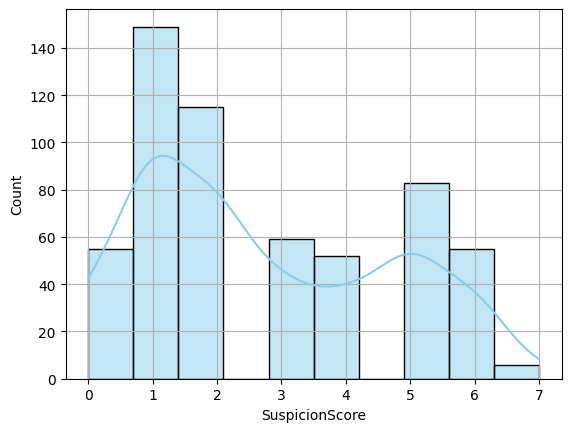

In [ ]:
sns.histplot(train['SuspicionScore'],kde=True,bins=10,color='skyblue')
plt.grid()
plt.show()

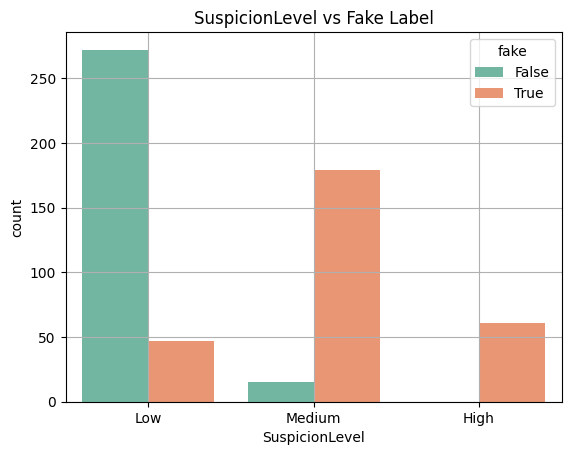

In [ ]:
sns.countplot(x='SuspicionLevel', hue='fake', data=train, palette='Set2')
plt.title('SuspicionLevel vs Fake Label')
plt.grid(True)
plt.show()


In [ ]:
print(train[['SuspicionScore', 'fake']].corr())


                SuspicionScore      fake
SuspicionScore        1.000000  0.780475
fake                  0.780475  1.000000


In [ ]:
x=train.drop(columns=['fake'])
y=train['fake']

In [ ]:
x_train=x.copy()

numeric_cols = [
    'nums/length username', 'fullname words', 'nums/length fullname',
    'description length', 'posts', 'followers', 'follows',
    'follower_follow_ratio', 'follow_post_ratio', 'SuspicionScore'
]


categorical_cols = ['profile pic', 'external URL', 'name==username', 'private', 'SuspicionLevel']

ss=StandardScaler()
x_train[numeric_cols]=ss.fit_transform(x_train[numeric_cols])

x_train=pd.get_dummies(x_train,columns=categorical_cols,drop_first=True)

le=LabelEncoder()
y_train=le.fit_transform(y)


In [ ]:
x_train.head(10)

,nums/length username,fullname words,nums/length fullname,description length,posts,followers,follows,follower_follow_ratio,follow_post_ratio,SuspicionScore,profile pic_True,external URL_True,name==username_True,private_True,SuspicionLevel_Medium,SuspicionLevel_High
0,0.505808,-1.386316,-0.289267,0.805681,-0.187600,-0.092867,0.485583,-0.064794,-0.132202,-0.883574,True,False,False,False,False,False
1,-0.768414,0.512838,-0.289267,0.567012,0.443721,-0.090957,0.026159,-0.064727,-0.209407,-0.883574,True,False,False,False,False,False
2,-0.296480,0.512838,-0.289267,-0.599814,-0.234825,-0.093790,-0.447419,-0.064785,-0.194746,-0.364463,True,False,False,True,False,False
3,-0.768414,-0.436739,-0.289267,1.574726,1.420528,-0.093510,0.154623,-0.064801,-0.211972,-0.883574,True,False,False,False,False,False
4,-0.768414,0.512838,-0.289267,-0.599814,-0.252223,-0.093799,-0.416936,-0.064792,-0.163388,-0.364463,True,False,False,True,False,False
5,-0.768414,2.411991,-0.289267,1.548207,0.587881,0.641535,-0.390807,0.008358,-0.213462,-1.402685,True,True,False,False,False,False
6,-0.768414,0.512838,-0.289267,0.726125,-0.227368,-0.093831,-0.361413,-0.064800,-0.185020,-0.883574,True,False,False,False,False,False
7,-0.768414,0.512838,-0.289267,-0.599814,-0.185115,-0.092781,-0.471370,-0.064580,-0.208329,-0.364463,True,False,False,False,False,False
8,-0.768414,-1.386316,-0.289267,1.283019,-0.088179,-0.091962,2.399490,-0.064800,-0.108755,-0.883574,True,False,False,False,False,False
9,-0.768414,0.512838,-0.289267,0.460937,0.262278,-0.079754,0.330990,-0.064549,-0.203871,-1.402685,True,True,False,False,False,False


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
x_test=test.copy()
x_test=x_test.drop(columns=['fake'])
x_test[numeric_cols]=ss.transform(x_test[numeric_cols])
x_test=pd.get_dummies(x_test,columns=categorical_cols,drop_first=True)

y_test=test['fake']
y_test=le.transform(y_test)

In [ ]:
x_test.head(5)

,nums/length username,fullname words,nums/length fullname,description length,posts,followers,follows,follower_follow_ratio,follow_post_ratio,SuspicionScore,profile pic_True,external URL_True,name==username_True,private_True,SuspicionLevel_Medium,SuspicionLevel_High
0,0.788969,-0.436739,2.346278,0.195749,-0.180144,-0.093429,0.103455,-0.064798,-0.166872,-0.364463,True,False,True,True,False,False
1,-0.768414,3.361567,-0.289267,1.097388,-0.259680,-0.093926,-0.547578,-0.064729,-0.210425,-0.364463,True,False,False,True,False,False
2,-0.768414,0.512838,-0.289267,1.574726,0.525743,-0.093605,0.173131,-0.064803,-0.208750,-0.883574,True,False,False,True,False,False
3,-0.768414,-0.436739,-0.289267,3.192371,0.411409,-0.077619,7.468403,-0.064778,-0.138033,-0.883574,True,False,False,True,False,False
4,1.591258,-0.436739,-0.289267,1.415613,-0.252223,-0.093718,-0.166538,-0.064801,-0.069720,-0.364463,True,False,False,True,False,False


In [ ]:
y_pred = model.predict(x_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[53  7]
 [ 5 55]]
              precision    recall  f1-score   support

           0       0.91      0.88      0.90        60
           1       0.89      0.92      0.90        60

    accuracy                           0.90       120
   macro avg       0.90      0.90      0.90       120
weighted avg       0.90      0.90      0.90       120



# models for grid search

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

logreg_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced'],
    'max_iter': [500, 1000]
}

logreg_search = GridSearchCV(LogisticRegression(), logreg_grid, cv=5, scoring='f1', n_jobs=-1)
logreg_search.fit(x_train, y_train)

print("🔍 Logistic Regression Best Params:", logreg_search.best_params_)
print("📊 Logistic Regression Best Score:", logreg_search.best_score_)
y_pred = logreg_search.predict(x_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


🔍 Logistic Regression Best Params: {'C': 0.1, 'class_weight': None, 'max_iter': 500, 'penalty': 'l2', 'solver': 'saga'}
📊 Logistic Regression Best Score: 0.9154179095792188
[[52  8]
 [ 2 58]]
              precision    recall  f1-score   support

           0       0.96      0.87      0.91        60
           1       0.88      0.97      0.92        60

    accuracy                           0.92       120
   macro avg       0.92      0.92      0.92       120
weighted avg       0.92      0.92      0.92       120



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_grid = {
    'n_estimators': [100, 200, 300, 500, 700],
    'max_depth': [10, 20, 30, 40, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', 0.5],
    'bootstrap': [True],
    'class_weight': [None, 'balanced', {0: 1, 1: 2}]
}


rf_search = GridSearchCV(RandomForestClassifier(), rf_grid, cv=5, scoring='f1', n_jobs=-1,verbose=3)
rf_search.fit(x_train, y_train)

print("🔍 Random Forest Best Params:", rf_search.best_params_)
print("📊 Random Forest Best Score:", rf_search.best_score_)
y_pred = rf_search.predict(x_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 3240 candidates, totalling 16200 fits
🔍 Random Forest Best Params: {'bootstrap': True, 'class_weight': None, 'max_depth': 40, 'max_features': 0.5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
📊 Random Forest Best Score: 0.9485883144306462
[[53  7]
 [ 1 59]]
              precision    recall  f1-score   support

           0       0.98      0.88      0.93        60
           1       0.89      0.98      0.94        60

    accuracy                           0.93       120
   macro avg       0.94      0.93      0.93       120
weighted avg       0.94      0.93      0.93       120



In [ ]:
from sklearn.svm import SVC
svc_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3],
}


svc_search = GridSearchCV(SVC(), svc_grid, cv=5, scoring='f1', n_jobs=-1,verbose=3)
svc_search.fit(x_train, y_train)

print("🔍 SVC Best Params:", svc_search.best_params_)
print("📊 SVC Best Score:", svc_search.best_score_)
y_pred = svc_search.predict(x_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 72 candidates, totalling 360 fits
🔍 SVC Best Params: {'C': 0.1, 'class_weight': None, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear', 'probability': True}
📊 SVC Best Score: 0.9116954026693026
[[50 10]
 [ 5 55]]
              precision    recall  f1-score   support

           0       0.91      0.83      0.87        60
           1       0.85      0.92      0.88        60

    accuracy                           0.88       120
   macro avg       0.88      0.88      0.87       120
weighted avg       0.88      0.88      0.87       120



In [ ]:
from sklearn.svm import SVC

svc_grid = {
    'C': [0.01, 0.1, 1, 10],
    'kernel': ['rbf', 'poly'],
    'gamma': [ 'auto', 0.01, 0.001],
    'degree': [2, 3, 4],
    'coef0': [0.0, 0.1, 0.5],
    'probability': [True]
}

svc_search = GridSearchCV(SVC(), svc_grid, cv=5, scoring='f1', n_jobs=-1,verbose=3)
svc_search.fit(x_train, y_train)

print("🔍 SVC Best Params:", svc_search.best_params_)
print("📊 SVC Best Score:", svc_search.best_score_)
y_pred = svc_search.predict(x_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 720 candidates, totalling 3600 fits
🔍 SVC Best Params: {'C': 10, 'class_weight': None, 'coef0': 0.5, 'degree': 2, 'gamma': 0.01, 'kernel': 'poly', 'probability': True}
📊 SVC Best Score: 0.9135787959086279
[[50 10]
 [ 6 54]]
              precision    recall  f1-score   support

           0       0.89      0.83      0.86        60
           1       0.84      0.90      0.87        60

    accuracy                           0.87       120
   macro avg       0.87      0.87      0.87       120
weighted avg       0.87      0.87      0.87       120



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_grid = {
    'n_neighbors': list(range(1, 15)),
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'leaf_size': [10, 20, 30, 40, 50],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}


knn_search = GridSearchCV(KNeighborsClassifier(), knn_grid, cv=5, scoring='f1', n_jobs=-1,verbose=3)
knn_search.fit(x_train, y_train)

print("🔍 KNN Best Params:", knn_search.best_params_)
print("📊 KNN Best Score:", knn_search.best_score_)
y_pred = knn_search.predict(x_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 3360 candidates, totalling 16800 fits
🔍 KNN Best Params: {'algorithm': 'auto', 'leaf_size': 10, 'metric': 'euclidean', 'n_neighbors': 12, 'p': 1, 'weights': 'distance'}
📊 KNN Best Score: 0.9192766615580716
[[55  5]
 [ 6 54]]
              precision    recall  f1-score   support

           0       0.90      0.92      0.91        60
           1       0.92      0.90      0.91        60

    accuracy                           0.91       120
   macro avg       0.91      0.91      0.91       120
weighted avg       0.91      0.91      0.91       120



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2', 0.5],
    'class_weight': [None, 'balanced']
}

dt_search = GridSearchCV(DecisionTreeClassifier(), dt_grid, cv=5, scoring='f1', n_jobs=-1,verbose=3)
dt_search.fit(x_train, y_train)

print("🔍 Decision Tree Best Params:", dt_search.best_params_)
print("📊 Decision Tree Best Score:", dt_search.best_score_)
y_pred = dt_search.predict(x_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 2592 candidates, totalling 12960 fits
🔍 Decision Tree Best Params: {'class_weight': 'balanced', 'criterion': 'log_loss', 'max_depth': 50, 'max_features': 0.5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'splitter': 'best'}
📊 Decision Tree Best Score: 0.9337222321637787
[[54  6]
 [ 5 55]]
              precision    recall  f1-score   support

           0       0.92      0.90      0.91        60
           1       0.90      0.92      0.91        60

    accuracy                           0.91       120
   macro avg       0.91      0.91      0.91       120
weighted avg       0.91      0.91      0.91       120



In [ ]:
from sklearn.naive_bayes import GaussianNB

gnb_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

gnb_search = GridSearchCV(GaussianNB(), gnb_grid, cv=5, scoring='f1', n_jobs=-1,verbose=3)
gnb_search.fit(x_train, y_train)

print("🔍 GaussianNB Best Params:", gnb_search.best_params_)
print("📊 GaussianNB Best Score:", gnb_search.best_score_)
y_pred = gnb_search.predict(x_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 4 candidates, totalling 20 fits
🔍 GaussianNB Best Params: {'var_smoothing': 1e-06}
📊 GaussianNB Best Score: 0.8346425256019794
[[27 33]
 [ 0 60]]
              precision    recall  f1-score   support

           0       1.00      0.45      0.62        60
           1       0.65      1.00      0.78        60

    accuracy                           0.72       120
   macro avg       0.82      0.72      0.70       120
weighted avg       0.82      0.72      0.70       120



In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Define parameter grid
xgb_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7, 10,None],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.4,0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3]
}

# Initialize classifier
xgb = XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Run GridSearch
xgb_search = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=3
)

xgb_search.fit(x_train, y_train)

# Evaluation
print("🔍 XGBoost Best Params:", xgb_search.best_params_)
print("📊 XGBoost Best Score:", xgb_search.best_score_)

y_pred = xgb_search.predict(x_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 4860 candidates, totalling 24300 fits
🔍 XGBoost Best Params: {'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.8}
📊 XGBoost Best Score: 0.9446518160580706
[[54  6]
 [ 1 59]]
              precision    recall  f1-score   support

           0       0.98      0.90      0.94        60
           1       0.91      0.98      0.94        60

    accuracy                           0.94       120
   macro avg       0.94      0.94      0.94       120
weighted avg       0.94      0.94      0.94       120



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:35:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# 📦 Imports
import pandas as pd
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 🧮 Load Data
train = pd.read_csv('/content/Insta_train.csv')
test = pd.read_csv('/content/Insta_test.csv')

train.rename(columns={'#posts': 'posts', '#followers': 'followers', '#follows': 'follows'}, inplace=True)
test.rename(columns={'#posts': 'posts', '#followers': 'followers', '#follows': 'follows'}, inplace=True)

# 🧠 Feature Engineering
def add_features(df):
    df['follower_follow_ratio'] = df['followers'] / (df['follows'] + 1)
    df['follow_post_ratio'] = df['follows'] / (df['posts'] + 1)
    df['SuspicionScore'] = (
        (~df['external URL']).astype(int) +
        (~df['profile pic']).astype(int) +
        (df['name==username']).astype(int) +
        (df['posts'] == 0).astype(int) +
        (df['followers'] < 50).astype(int) +
        ((df['follower_follow_ratio'] < 0.1) & (df['followers'] > 1000)).astype(int) +
        ((df['follow_post_ratio'] > 20) & (df['posts'] < 10)).astype(int) +
        (df['description length'] == 0).astype(int)
    )
    df['SuspicionLevel'] = pd.cut(df['SuspicionScore'], bins=[-1, 2, 5, 8], labels=['Low', 'Medium', 'High'])
    return df

train = add_features(train)
test = add_features(test)

# 🧹 Preprocessing
numeric_cols = [
    'nums/length username', 'fullname words', 'nums/length fullname',
    'description length', 'posts', 'followers', 'follows',
    'follower_follow_ratio', 'follow_post_ratio', 'SuspicionScore'
]
categorical_cols = ['profile pic', 'external URL', 'name==username', 'private', 'SuspicionLevel']

# Convert categorical to bool
for col in categorical_cols + ['fake']:
    train[col] = train[col].astype(bool)
    test[col] = test[col].astype(bool)

# Split features and target
x = train.drop(columns=['fake'])
y = train['fake']
x_test = test.drop(columns=['fake'])
y_test = test['fake']

# Scale numeric features
ss = StandardScaler()
x[numeric_cols] = ss.fit_transform(x[numeric_cols])
x_test[numeric_cols] = ss.transform(x_test[numeric_cols])

# One-hot encode categorical features
x = pd.get_dummies(x, columns=categorical_cols, drop_first=True)
x_test = pd.get_dummies(x_test, columns=categorical_cols, drop_first=True)

# Align columns
x_test = x_test.reindex(columns=x.columns, fill_value=0)

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)
y_test = le.transform(y_test)

# 🔁 Train-Test Split (optional if not using test set directly)
X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

# 🔗 Pipeline: Polynomial + Scaling + Logistic Regression
pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))
])

# 🔍 GridSearch
param_grid = {
    'poly__degree': [2, 3],
    'logreg__C': [0.01, 0.1, 1, 10],
    'logreg__penalty': ['l1', 'l2'],
    'logreg__solver': ['liblinear', 'saga'],
    'logreg__class_weight': [None, 'balanced']
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', verbose=3, n_jobs=-1)
grid.fit(X_train, y_train)

# 📊 Evaluation
print("🔍 Best Parameters:", grid.best_params_)
print("📈 Best F1 Score (CV):", grid.best_score_)

y_pred = grid.predict(x_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 64 candidates, totalling 320 fits
🔍 Best Parameters: {'logreg__C': 0.1, 'logreg__class_weight': None, 'logreg__penalty': 'l1', 'logreg__solver': 'liblinear', 'poly__degree': 2}
📈 Best F1 Score (CV): 0.9324662310869207
[[53  7]
 [ 8 52]]
              precision    recall  f1-score   support

           0       0.87      0.88      0.88        60
           1       0.88      0.87      0.87        60

    accuracy                           0.88       120
   macro avg       0.88      0.88      0.87       120
weighted avg       0.88      0.88      0.87       120



# voting classifier

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix


logreg = LogisticRegression(C=0.1, penalty='l2', solver='saga', class_weight=None, max_iter=500)
rf = RandomForestClassifier(n_estimators=100, max_depth=20, min_samples_split=5,
                            min_samples_leaf=2, max_features='sqrt', bootstrap=False, class_weight=None)
knn = KNeighborsClassifier(n_neighbors=7, weights='distance', algorithm='auto', leaf_size=20, metric='euclidean')
xgb = XGBClassifier(colsample_bytree=1.0, gamma=0.1, learning_rate=0.01, max_depth=5,
                    min_child_weight=1, n_estimators=200, subsample=0.8,
                    use_label_encoder=False, eval_metric='logloss', random_state=42)

voting_clf = VotingClassifier(
    estimators=[
        ('logreg', logreg),
        ('rf', rf),
        ('knn', knn),
        ('xgb', xgb)
    ],
    voting='soft',  # Use soft voting for probability-based aggregation
    weights=[2, 3, 2, 4],  # Optional: weight stronger models
    n_jobs=-1
)


voting_clf.fit(x_train, y_train)
y_pred = voting_clf.predict(x_test)


print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


ValueError: Found input variables with inconsistent numbers of samples: [574, 460]

## power transfromer

In [ ]:
train=pd.read_csv('/content/Insta_train.csv')
test=pd.read_csv("/content/Insta_test.csv")

train.drop_duplicates(inplace=True)
train.rename(columns={
    '#posts': 'posts',
    '#followers': 'followers',
    '#follows': 'follows'
}, inplace=True)

test.rename(columns={
    '#posts': 'posts',
    '#followers': 'followers',
    '#follows': 'follows'
}, inplace=True)

def add_features(df):
  df['follower_follow_ratio'] = df['followers'] / (df['follows'] + 1)
  df['follow_post_ratio'] = df['follows'] / (df['posts'] + 1)

  df['SuspicionScore'] = (
      (~df['external URL']).astype(int) +
      (~df['profile pic']).astype(int) +
      (df['name==username']).astype(int) +
      (df['posts'] == 0).astype(int) +
      (df['followers'] < 50).astype(int) +
      ((df['follower_follow_ratio'] < 0.1) &
      (df['followers'] > 1000)).astype(int) +
      ((df['follow_post_ratio'] > 20) &
      (df['posts'] < 10)).astype(int) +
      (df['description length'] == 0).astype(int)
      )
  df['SuspicionLevel'] = pd.cut(df['SuspicionScore'],
      bins=[-1, 2, 5, 8],
      labels=['Low', 'Medium', 'High']
  )
  return df

train=add_features(train)
test=add_features(test)

x=train.drop(columns=['fake'])
y=train['fake']


In [ ]:
from sklearn.preprocessing import PowerTransformer

x_train=x.copy()

numeric_cols = [
    'nums/length username', 'fullname words', 'nums/length fullname',
    'description length', 'posts', 'followers', 'follows',
    'follower_follow_ratio', 'follow_post_ratio', 'SuspicionScore'
]


categorical_cols = ['profile pic', 'external URL', 'name==username', 'private', 'SuspicionLevel']

pt=PowerTransformer(method='yeo-johnson',standardize=True)
x_train[numeric_cols]=pt.fit_transform(x_train[numeric_cols])

x_train=pd.get_dummies(x_train,columns=categorical_cols,drop_first=True)

le=LabelEncoder()
y_train=le.fit_transform(y)




In [ ]:
x_train.head(10)

,nums/length username,fullname words,nums/length fullname,description length,posts,followers,follows,follower_follow_ratio,follow_post_ratio,SuspicionScore,profile pic_1,external URL_1,name==username_1,private_1,SuspicionLevel_Medium,SuspicionLevel_High
0,0.918308,-2.108782,-0.335234,1.277221,0.519301,0.759862,1.049916,0.095545,0.495814,-0.898852,True,False,False,False,False,False
1,-0.899665,0.704495,-0.335234,1.229119,1.357959,1.103279,0.625962,1.370264,-1.126597,-0.898852,True,False,False,False,False,False
2,0.038100,0.704495,-0.335234,-0.849152,0.136798,0.057952,-0.426091,0.478024,-0.354427,-0.310461,True,False,False,True,False,False
3,-0.899665,-0.359069,-0.335234,1.379750,1.647758,0.435821,0.767502,-0.330588,-1.437179,-0.898852,True,False,False,False,False,False
4,-0.899665,0.704495,-0.335234,-0.849152,-0.195703,0.036776,-0.285514,0.209762,0.219134,-0.310461,True,False,False,True,False,False
5,-0.899665,2.088117,-0.335234,1.377054,1.421779,2.554669,-0.184948,2.289357,-1.703856,-1.513356,True,True,False,False,False,False
6,-0.899665,0.704495,-0.335234,1.262453,0.226124,-0.051560,-0.087131,-0.268361,-0.111086,-0.898852,True,False,False,False,False,False
7,-0.899665,0.704495,-0.335234,-0.849152,0.532072,0.786421,-0.563146,1.838547,-1.027813,-0.310461,True,False,False,False,False,False
8,-0.899665,-2.108782,-0.335234,1.347443,0.847070,0.967981,1.899713,-0.284475,0.636952,-0.898852,True,False,False,False,False,False
9,-0.899665,0.704495,-0.335234,1.203414,1.253885,1.580527,0.929449,1.879588,-0.724784,-1.513356,True,True,False,False,False,False


In [ ]:
x_test=test.copy()
x_test=x_test.drop(columns=['fake'])
x_test[numeric_cols]=pt.transform(x_test[numeric_cols])
x_test=pd.get_dummies(x_test,columns=categorical_cols,drop_first=True)

y_test=test['fake']
y_test=le.transform(y_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

logreg_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced'],
    'max_iter': [500, 1000]
}

logreg_search = GridSearchCV(LogisticRegression(), logreg_grid, cv=5, scoring='f1', n_jobs=-1)
logreg_search.fit(x_train, y_train)

print("🔍 Logistic Regression Best Params:", logreg_search.best_params_)
print("📊 Logistic Regression Best Score:", logreg_search.best_score_)
y_pred = logreg_search.predict(x_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


🔍 Logistic Regression Best Params: {'C': 1, 'class_weight': None, 'max_iter': 500, 'penalty': 'l1', 'solver': 'liblinear'}
📊 Logistic Regression Best Score: 0.9325340762277327
[[52  8]
 [ 4 56]]
              precision    recall  f1-score   support

           0       0.93      0.87      0.90        60
           1       0.88      0.93      0.90        60

    accuracy                           0.90       120
   macro avg       0.90      0.90      0.90       120
weighted avg       0.90      0.90      0.90       120



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_grid = {
    'n_estimators': [200,100, 300, 500],
    'max_depth': [10, 30,40, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', 0.5],
}


rf_search = GridSearchCV(RandomForestClassifier(), rf_grid, cv=5, scoring='f1', n_jobs=-1,verbose=3)
rf_search.fit(x_train, y_train)

print("🔍 Random Forest Best Params:", rf_search.best_params_)
print("📊 Random Forest Best Score:", rf_search.best_score_)
y_pred = rf_search.predict(x_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 720 candidates, totalling 3600 fits
🔍 Random Forest Best Params: {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 6, 'min_samples_split': 2, 'n_estimators': 200}
📊 Random Forest Best Score: 0.9466200075082108
[[54  6]
 [ 1 59]]
              precision    recall  f1-score   support

           0       0.98      0.90      0.94        60
           1       0.91      0.98      0.94        60

    accuracy                           0.94       120
   macro avg       0.94      0.94      0.94       120
weighted avg       0.94      0.94      0.94       120



In [ ]:
from sklearn.svm import SVC

svc_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3],  # for poly
    'class_weight': [None, 'balanced'],
    'probability': [True]
}

svc_search = GridSearchCV(SVC(), svc_grid, cv=5, scoring='f1', n_jobs=-1,verbose=3)
svc_search.fit(x_train, y_train)

print("🔍 SVC Best Params:", svc_search.best_params_)
print("📊 SVC Best Score:", svc_search.best_score_)
y_pred = svc_search.predict(x_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 72 candidates, totalling 360 fits
🔍 SVC Best Params: {'C': 10, 'class_weight': None, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear', 'probability': True}
📊 SVC Best Score: 0.9364760164328441
[[54  6]
 [ 3 57]]
              precision    recall  f1-score   support

           0       0.95      0.90      0.92        60
           1       0.90      0.95      0.93        60

    accuracy                           0.93       120
   macro avg       0.93      0.93      0.92       120
weighted avg       0.93      0.93      0.92       120



In [ ]:
from sklearn.svm import SVC

svc_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'degree': [2, 3, 4],  # for
    'coef0': [0.0, 0.1, 0.5],  # for poly/sigmoid
    'class_weight': [None, 'balanced'],
    'probability': [True]
}


svc_search = GridSearchCV(SVC(), svc_grid, cv=5, scoring='f1', n_jobs=-1,verbose=3)
svc_search.fit(x_train, y_train)

print("🔍 SVC Best Params:", svc_search.best_params_)
print("📊 SVC Best Score:", svc_search.best_score_)
y_pred = svc_search.predict(x_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 720 candidates, totalling 3600 fits
🔍 SVC Best Params: {'C': 1, 'class_weight': None, 'coef0': 0.5, 'degree': 2, 'gamma': 'auto', 'kernel': 'poly', 'probability': True}
📊 SVC Best Score: 0.9361317496356305
[[56  4]
 [ 3 57]]
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        60
           1       0.93      0.95      0.94        60

    accuracy                           0.94       120
   macro avg       0.94      0.94      0.94       120
weighted avg       0.94      0.94      0.94       120



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_grid = {
    'n_neighbors': list(range(1, 15)),  # finer sweep
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'leaf_size': [10, 20, 30, 40, 50],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]  # for Minkowski distance
}


knn_search = GridSearchCV(KNeighborsClassifier(), knn_grid, cv=5, scoring='f1', n_jobs=-1,verbose=3)
knn_search.fit(x_train, y_train)

print("🔍 KNN Best Params:", knn_search.best_params_)
print("📊 KNN Best Score:", knn_search.best_score_)
y_pred = knn_search.predict(x_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 3360 candidates, totalling 16800 fits
🔍 KNN Best Params: {'algorithm': 'auto', 'leaf_size': 10, 'metric': 'manhattan', 'n_neighbors': 9, 'p': 1, 'weights': 'distance'}
📊 KNN Best Score: 0.9216801232243339
[[54  6]
 [ 3 57]]
              precision    recall  f1-score   support

           0       0.95      0.90      0.92        60
           1       0.90      0.95      0.93        60

    accuracy                           0.93       120
   macro avg       0.93      0.93      0.92       120
weighted avg       0.93      0.93      0.92       120



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2', 0.5],
    'class_weight': [None, 'balanced']
}

dt_search = GridSearchCV(DecisionTreeClassifier(), dt_grid, cv=5, scoring='f1', n_jobs=-1,verbose=3)
dt_search.fit(x_train, y_train)

print("🔍 Decision Tree Best Params:", dt_search.best_params_)
print("📊 Decision Tree Best Score:", dt_search.best_score_)
y_pred = dt_search.predict(x_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 2592 candidates, totalling 12960 fits
🔍 Decision Tree Best Params: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 50, 'max_features': 0.5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'best'}
📊 Decision Tree Best Score: 0.9312383665085109
[[54  6]
 [ 4 56]]
              precision    recall  f1-score   support

           0       0.93      0.90      0.92        60
           1       0.90      0.93      0.92        60

    accuracy                           0.92       120
   macro avg       0.92      0.92      0.92       120
weighted avg       0.92      0.92      0.92       120



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 1.0],
    'max_features': ['sqrt', 'log2']
}

grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42),
                       param_grid_gb,
                       cv=5,
                       scoring='f1_weighted',
                       n_jobs=-1,
                       verbose=3)


grid_gb.fit(x_train, y_train)

# +
gb_best = grid_gb.best_estimator_
y_pred = gb_best.predict(x_test)

# Evaluation
print("🔍 Gradient Boosting Best Parameters:", grid_gb.best_params_)
print("📊Gradient Boosting Best Score:", grid_gb.best_score_)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 972 candidates, totalling 4860 fits
🔍 Gradient Boosting Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 0.8}
📊Gradient Boosting Best Score: 0.9405382330890408
[[55  5]
 [ 3 57]]
              precision    recall  f1-score   support

           0       0.95      0.92      0.93        60
           1       0.92      0.95      0.93        60

    accuracy                           0.93       120
   macro avg       0.93      0.93      0.93       120
weighted avg       0.93      0.93      0.93       120



In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Define parameter
xgb_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7, 10,None],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.4,0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3]
}

# Initialize classif
xgb = XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

#
xgb_search = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=3
)

xgb_search.fit(x_train, y_train)

# Evalua
print("🔍 XGBoost Best Params:", xgb_search.best_params_)
print("📊 XGBoost Best Score:", xgb_search.best_score_)

y_pred = xgb_search.predict(x_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 4860 candidates, totalling 24300 fits
🔍 XGBoost Best Params: {'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.8}
📊 XGBoost Best Score: 0.9446518160580706
[[54  6]
 [ 1 59]]
              precision    recall  f1-score   support

           0       0.98      0.90      0.94        60
           1       0.91      0.98      0.94        60

    accuracy                           0.94       120
   macro avg       0.94      0.94      0.94       120
weighted avg       0.94      0.94      0.94       120



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:15:00] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
